# Faz 3: Veri Hikayesi Anlatimi (Acik Uclu Analiz)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 150

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

DATA_DIR = "../data"
FIGURES_DIR = "../outputs/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Pickle dosyalarindan oku
df_tahsilat = pd.read_pickle(os.path.join(DATA_DIR, "tahsilat.pkl"))
df_tahsilat_1 = pd.read_pickle(os.path.join(DATA_DIR, "tahsilat_1.pkl"))
df_tahakkuk = pd.read_pickle(os.path.join(DATA_DIR, "tahakkuk.pkl"))
df_tahakkuk_1 = pd.read_pickle(os.path.join(DATA_DIR, "tahakkuk_1.pkl"))
df_tahakkuk_2 = pd.read_pickle(os.path.join(DATA_DIR, "tahakkuk_2.pkl"))

# Tahakkuk birlestirme ve tarih donusumu
df_tahakkuk_all = pd.concat([df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2], ignore_index=True)
for df_tmp in [df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2, df_tahakkuk_all]:
    df_tmp["mali_yil_donem"] = pd.to_datetime(df_tmp["mali_yil_donem"])
df_tahakkuk_all["ay"] = df_tahakkuk_all["mali_yil_donem"].dt.month

AY_ISIMLERI = {1:"Oca", 2:"Sub", 3:"Mar", 4:"Nis", 5:"May", 6:"Haz",
               7:"Tem", 8:"Agu", 9:"Eyl", 10:"Eki", 11:"Kas", 12:"Ara"}

# Odeme davranisi onceden hesapla
gec_sutunlar = [col for col in df_tahsilat_1.columns if col.startswith("Son Ödeme (")]
df_tahsilat_1["gec_odeme_var"] = df_tahsilat_1[gec_sutunlar].notna().any(axis=1)
df_tahsilat_1["zamaninda_odeme"] = (
    df_tahsilat_1["Son Ödeme Tarihinden Önceki Tahsilat"].notna() |
    df_tahsilat_1["Son Ödeme Tarihindeki Tahsilat"].notna()
)

print("Veri yuklendi.")
print(f"Tahakkuk (birlesik): {df_tahakkuk_all.shape}")
print(f"Tahsilat: {df_tahsilat.shape}")
print(f"Tahsilat 1: {df_tahsilat_1.shape}")

Veri yuklendi.
Tahakkuk (birlesik): (1185698, 11)
Tahsilat: (636993, 9)
Tahsilat 1: (917632, 24)


,Kayit,Ortalama,Medyan,Std,Min,Max
ilce,,,,,,
GÖYNÜCEK,295223,89.670,45.090,742.280,-4208.640,105687.690
GÜMÜŞHACIKÖY,765657,97.340,48.310,1077.760,-25370.640,153575.730
HAMAMÖZÜ,124818,70.870,40.560,389.220,-1242.990,25941.600


Hesap Sınıfı,1 SAYILI CETVELDE YER ALAN KAMU İDARESİ,Aritma Tesisleri,Balıkçılık ve Su Ürünleri Yetiştiriciliğ,Belediye,Belediye Park Bahçe Aydınlatma,"Bina Ort Kul (Asn,Hidr,Kapıcı Dai vb.)",Büyükbaş-Küçükbaş Hayvancılık,Cemevleri,Diyanet Kuran Kursu,Doğal Afet Barınma,"Kar Amacı Güden Dernek,Vakıf,Müze",Karayolları Genel Müdürlüğü Aydınlatma,Köy İçme Suyu Temini ve Dağıtımı Tesisi,Lisansız Üreticiler,Lisansız Üreticiler - Resmi Daire,Mesken,Muhtarlık Hizmet Binaları,Resmi Daire,Resmi Daire Lojman,"Resmi Hayır Kurumları,Dernek,Vakıf,Müze","Resmi SAĞLIK KURULUŞLARI,RESMİ SPOR TES.","Resmi Üniversite,Yük.Okul,Kurs,Yurt,Okul",Resmi İbadethane Isıtma/Soğutma/Lojman,Sanayi,Süt Toplama Merkezi,Tarımsal Faaliyetler (Kooperatif),Tarımsal Faaliyetler (Şahıs),Ticari Faaliyet - Yazıhane,Ölçümsüz Aboneler (Resmi Daire),İbadethane Aydınlatma,İbadethane Isıtma/Soğutma/Lojman,İktisadi İşletmeleri Hariç Dernek ve Vkf,İç Tüketim,İçme-Kullanma Suyu (Belediye),Şantiye ve Geçici Aboneler,Şantiye ve Geçici Aboneler (Belediye),Şehit Aileleri ve Gaziler
ilce,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GÖYNÜCEK,0.730,0.000,0.000,0.280,0.000,0.220,0.350,0.090,0.000,0.000,0.020,0.000,0.440,0.010,0.000,87.300,0.070,0.190,0.030,0.010,0.040,0.050,0.000,0.010,0.100,0.280,0.890,6.850,0.000,0.280,1.010,0.040,0.020,0.010,0.420,0.000,0.270
GÜMÜŞHACIKÖY,0.630,0.000,0.010,0.150,0.050,0.310,0.090,0.080,0.010,0.020,0.020,0.010,0.130,0.020,0.000,85.960,0.020,0.090,0.050,0.000,0.030,0.040,0.000,0.010,0.090,0.100,1.830,8.310,0.000,0.240,0.750,0.010,0.010,0.040,0.660,0.000,0.230
HAMAMÖZÜ,1.210,0.000,0.050,0.120,0.000,0.400,0.090,0.030,0.000,0.000,0.020,0.000,0.140,0.000,0.000,88.670,0.020,0.120,0.140,0.100,0.090,0.040,0.000,0.040,0.100,0.010,0.530,5.980,0.000,0.420,1.160,0.060,0.000,0.030,0.320,0.000,0.100


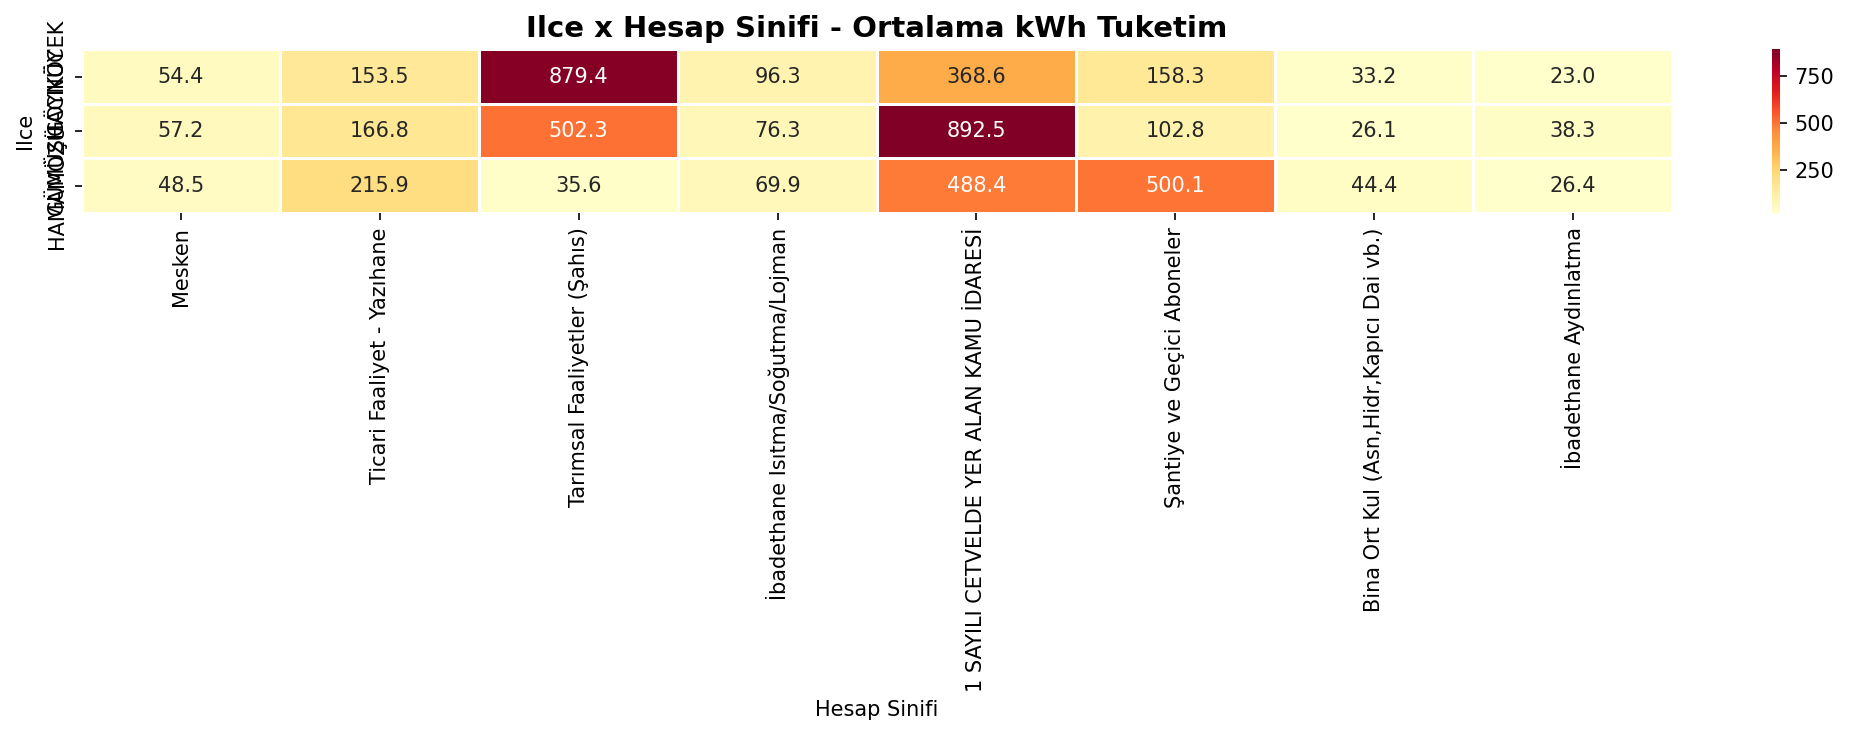

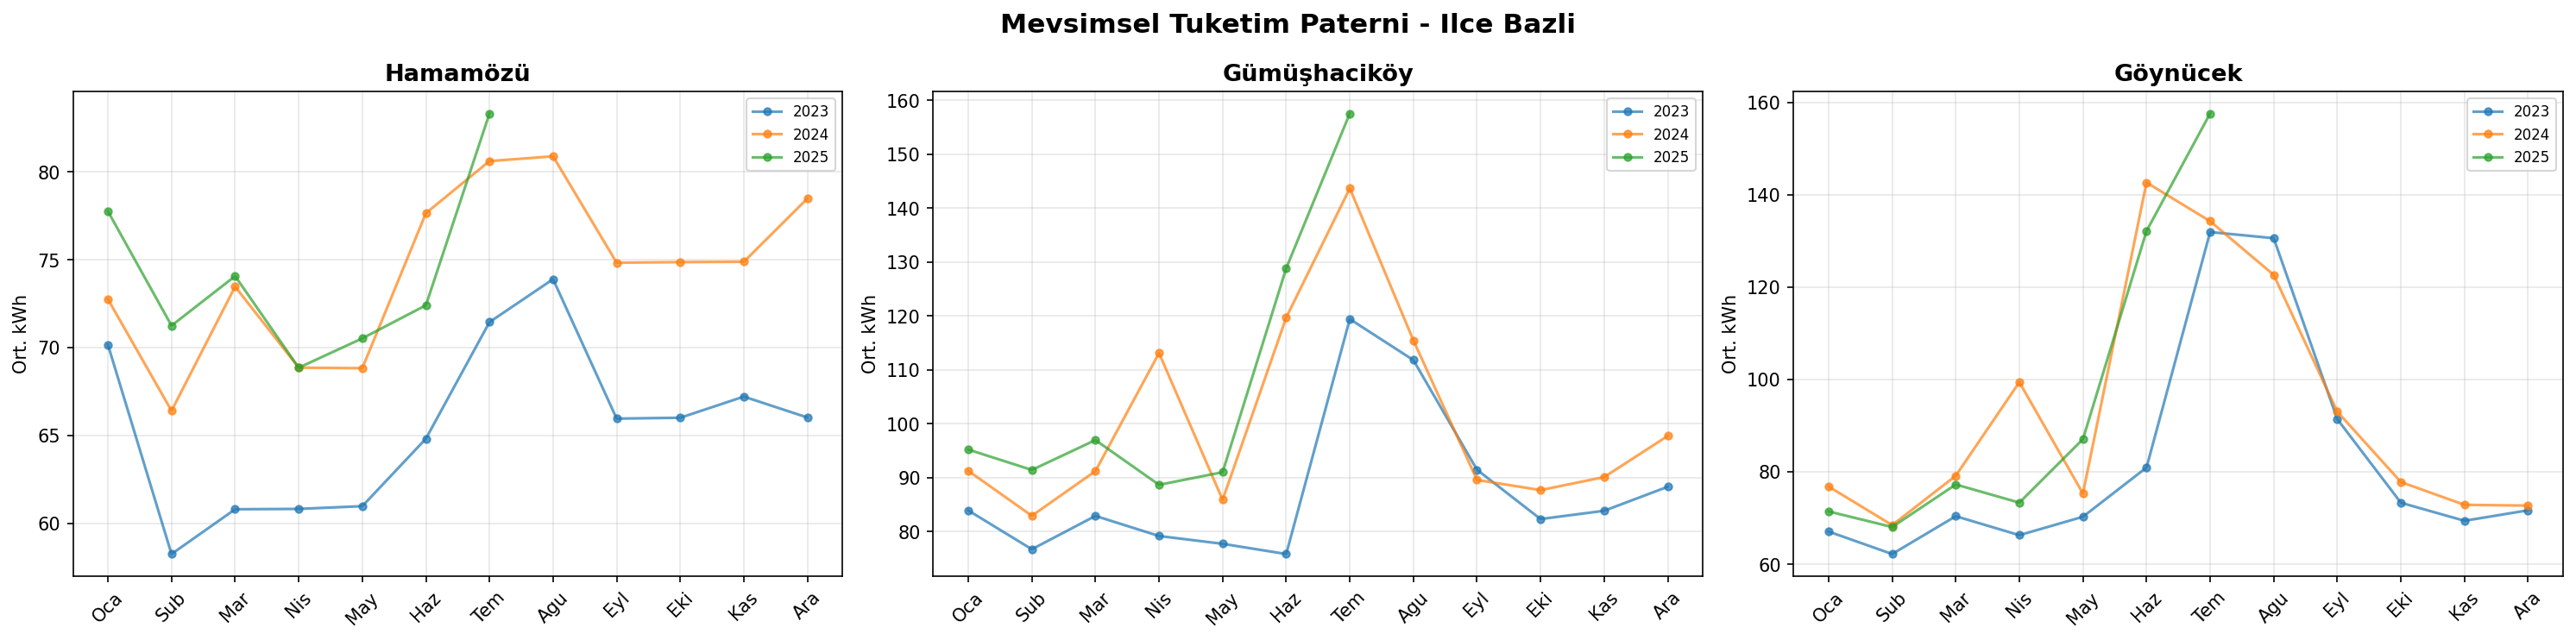

In [2]:
# 3.1 Ilce Karsilastirma Analizi

# Ilce bazli genel istatistikler
ilce_karsilastirma = df_tahakkuk_all.groupby("ilce")["kwh"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)
ilce_karsilastirma.columns = ["Kayit", "Ortalama", "Medyan", "Std", "Min", "Max"]
display(ilce_karsilastirma)

# Hesap sinifi oranlari - ilce bazli
ilce_hesap = df_tahakkuk_all.groupby(["ilce", "Hesap Sınıfı"]).size().unstack(fill_value=0)
ilce_hesap_oran = ilce_hesap.div(ilce_hesap.sum(axis=1), axis=0) * 100
display(ilce_hesap_oran.round(2))

# Heatmap - Ilce x Hesap Sinifi ortalama tuketim
ilce_hesap_mean = df_tahakkuk_all.groupby(["ilce", "Hesap Sınıfı"])["kwh"].mean().unstack(fill_value=0)
top_hesap = df_tahakkuk_all["Hesap Sınıfı"].value_counts().head(8).index

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(ilce_hesap_mean[top_hesap], annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Ilce x Hesap Sinifi - Ortalama kWh Tuketim", fontsize=14, fontweight="bold")
ax.set_ylabel("Ilce")
ax.set_xlabel("Hesap Sinifi")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/ilce_hesap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Mevsimsel karsilastirma
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Mevsimsel Tuketim Paterni - Ilce Bazli", fontsize=15, fontweight="bold")

for ax, ilce in zip(axes, ["HAMAMÖZÜ", "GÜMÜŞHACIKÖY", "GÖYNÜCEK"]):
    data = df_tahakkuk_all[df_tahakkuk_all["ilce"] == ilce]
    aylik = data.groupby([data["mali_yil_donem"].dt.year, "ay"])["kwh"].mean().reset_index()
    aylik.columns = ["yil", "ay", "kwh"]
    for yil in sorted(aylik["yil"].unique()):
        yil_data = aylik[aylik["yil"] == yil].sort_values("ay")
        ax.plot(yil_data["ay"], yil_data["kwh"], marker="o", markersize=4, alpha=0.7, label=str(yil))
    ax.set_title(ilce.title(), fontsize=13, fontweight="bold")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([AY_ISIMLERI[i] for i in range(1, 13)], rotation=45)
    ax.set_ylabel("Ort. kWh")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/mevsimsel_ilce.png", dpi=150, bbox_inches="tight")
plt.show()

,Musteri_Sayisi,Ort_kWh,Ort_Gec_Oran,Oran (%)
segment,,,,
Degerli Musteri,6213,153.680,2.200,22.000
Ideal Musteri,6143,16.060,1.170,21.700
Riskli Musteri,8793,120.060,70.930,31.100
Takip Gerektiren,7141,95.520,22.980,25.200


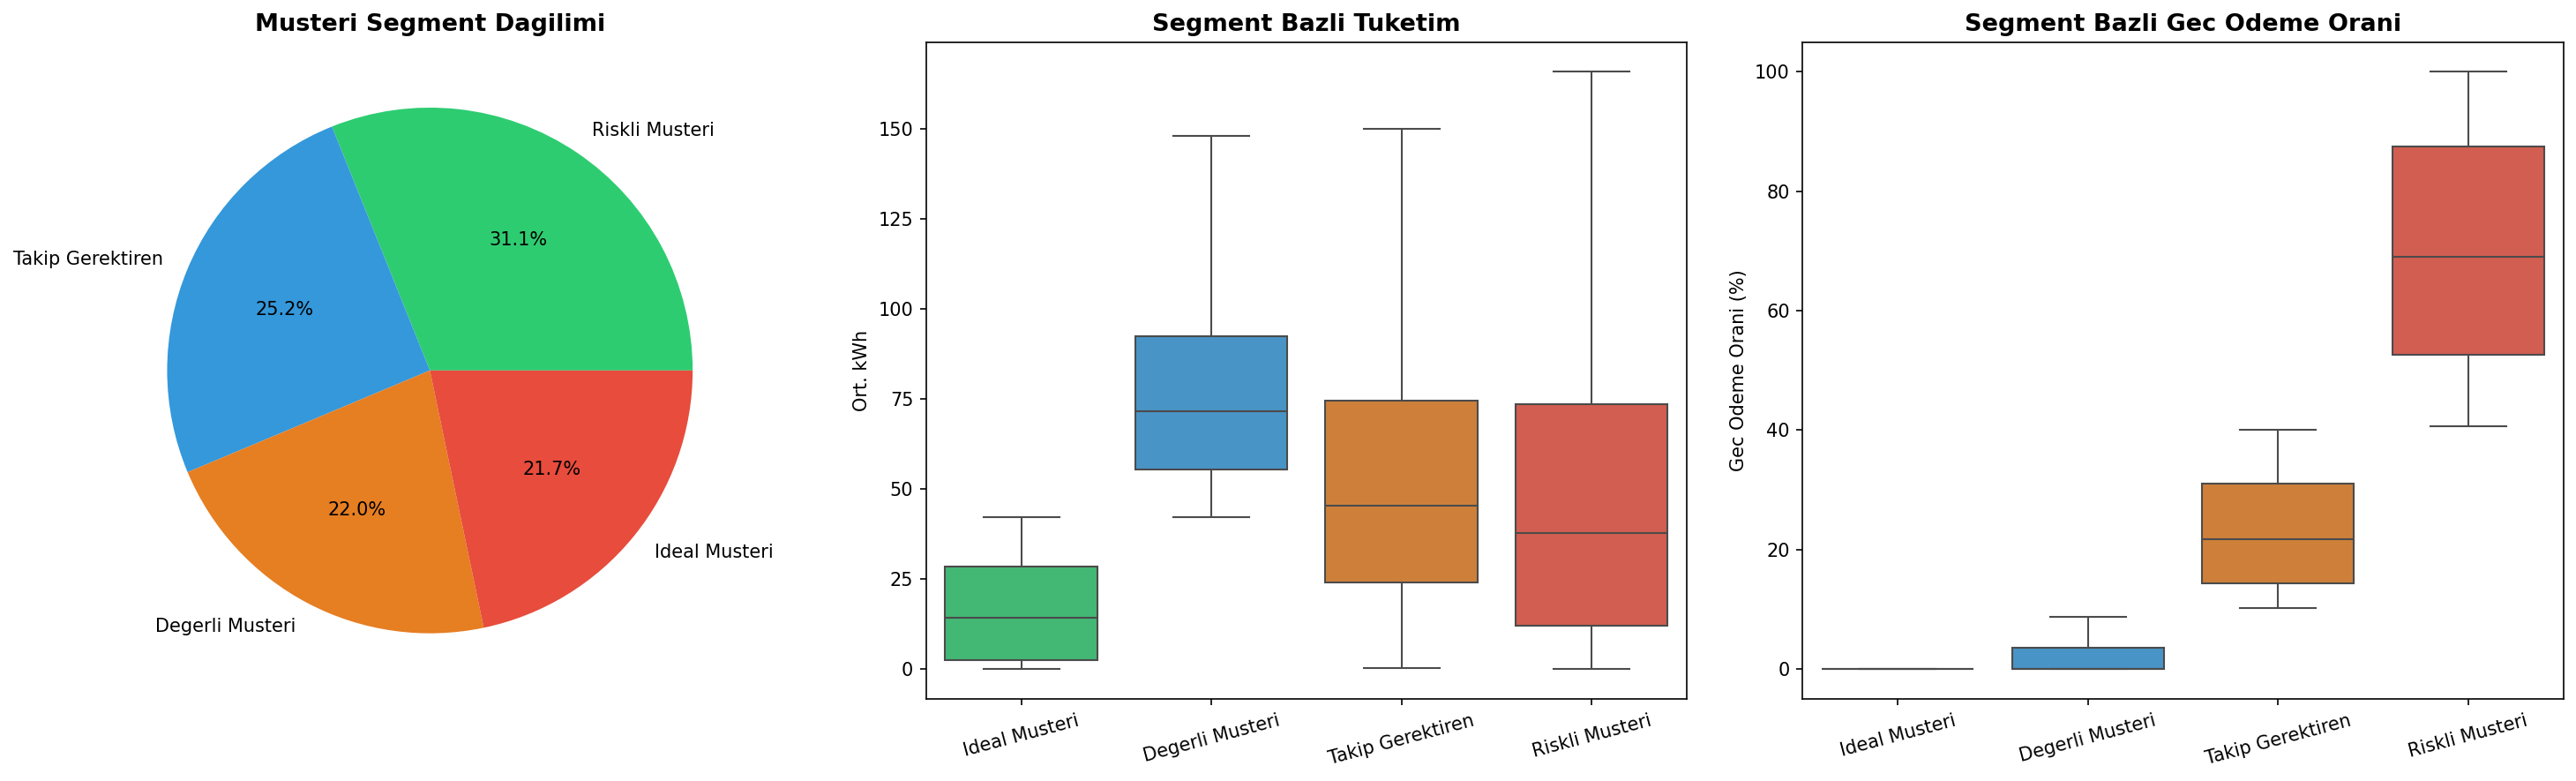

In [3]:
# 3.2 Musteri Segmentasyonu

# Musteri bazli tuketim profili
musteri_tuketim = df_tahakkuk_all.groupby("sozlesme_hesap_no").agg(
    ort_kwh=("kwh", "mean"),
    toplam_kwh=("kwh", "sum"),
    kayit_sayisi=("kwh", "count"),
    std_kwh=("kwh", "std"),
    ilce=("ilce", "first"),
    hesap_sinifi=("Hesap Sınıfı", "first")
).reset_index()
musteri_tuketim["std_kwh"] = musteri_tuketim["std_kwh"].fillna(0)

# Tuketim segmentleri (quantile bazli)
musteri_tuketim["tuketim_segment"] = pd.qcut(
    musteri_tuketim["ort_kwh"], q=4, labels=["Dusuk", "Orta-Dusuk", "Orta-Yuksek", "Yuksek"]
)

# Odeme profili
odeme_profil = df_tahsilat_1.groupby("Söz.hsp.(bağımsız)").agg(
    toplam_fatura=("gec_odeme_var", "count"),
    gec_fatura=("gec_odeme_var", "sum"),
    zamaninda_fatura=("zamaninda_odeme", "sum")
).reset_index()
odeme_profil.columns = ["sozlesme_hesap_no", "toplam_fatura", "gec_fatura", "zamaninda_fatura"]
odeme_profil["gec_oran"] = (odeme_profil["gec_fatura"] / odeme_profil["toplam_fatura"] * 100).round(1)

# Tuketim + odeme birlestir
musteri_full = musteri_tuketim.merge(odeme_profil, on="sozlesme_hesap_no", how="left")
musteri_full["gec_oran"] = musteri_full["gec_oran"].fillna(0)

musteri_full["odeme_segment"] = pd.cut(
    musteri_full["gec_oran"], bins=[-1, 10, 40, 100], labels=["Zamaninda", "Kismen Gec", "Surekli Gec"]
)

def segment_belirle(row):
    if row["tuketim_segment"] in ["Dusuk", "Orta-Dusuk"] and row["odeme_segment"] == "Zamaninda":
        return "Ideal Musteri"
    elif row["tuketim_segment"] in ["Orta-Yuksek", "Yuksek"] and row["odeme_segment"] == "Zamaninda":
        return "Degerli Musteri"
    elif row["odeme_segment"] == "Surekli Gec":
        return "Riskli Musteri"
    else:
        return "Takip Gerektiren"

musteri_full["segment"] = musteri_full.apply(segment_belirle, axis=1)

# Segment ozeti
segment_ozet = musteri_full.groupby("segment").agg(
    Musteri_Sayisi=("sozlesme_hesap_no", "count"),
    Ort_kWh=("ort_kwh", "mean"),
    Ort_Gec_Oran=("gec_oran", "mean")
).round(2)
segment_ozet["Oran (%)"] = (segment_ozet["Musteri_Sayisi"] / len(musteri_full) * 100).round(1)
display(segment_ozet)

# Gorsellestirme
segment_order = ["Ideal Musteri", "Degerli Musteri", "Takip Gerektiren", "Riskli Musteri"]
colors_seg = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

segment_counts = musteri_full["segment"].value_counts()
axes[0].pie(segment_counts.values, labels=segment_counts.index, autopct="%1.1f%%",
            colors=colors_seg, textprops={"fontsize": 10})
axes[0].set_title("Musteri Segment Dagilimi", fontsize=13, fontweight="bold")

sns.boxplot(data=musteri_full, x="segment", y="ort_kwh", order=segment_order,
            palette=colors_seg, ax=axes[1], showfliers=False)
axes[1].set_title("Segment Bazli Tuketim", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Ort. kWh")
axes[1].tick_params(axis="x", rotation=15)

sns.boxplot(data=musteri_full, x="segment", y="gec_oran", order=segment_order,
            palette=colors_seg, ax=axes[2], showfliers=False)
axes[2].set_title("Segment Bazli Gec Odeme Orani", fontsize=13, fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Gec Odeme Orani (%)")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/musteri_segmentasyon.png", dpi=150, bbox_inches="tight")
plt.show()

,Kayit Sayisi,Oran (%)
Banka Tahsilati,628933,98.700
Mahsuben Tahsilat,7542,1.200
Nakit Tahsilat,523,0.100
Kredi Karti,0,0.000


,Hesap Sınıfı,toplam_kayit,gec_kayit,zamaninda_kayit,gec_oran
34,İçme-Kullanma Suyu (Belediye),253,216,40,85.400
4,Belediye Park Bahçe Aydınlatma,210,177,34,84.300
36,Şantiye ve Geçici Aboneler (Belediye),6,5,1,83.300
7,Cemevleri,308,240,115,77.900
28,Ölçümsüz Aboneler (Belediye),29,20,9,69.000
3,Belediye,1321,789,543,59.700
1,Aritma Tesisleri,26,15,18,57.700
12,Köy İçme Suyu Temini ve Dağıtımı Tesisi,1322,736,977,55.700
25,Tarımsal Faaliyetler (Kooperatif),929,488,709,52.500
18,Resmi Daire Lojman,272,141,131,51.800


,İlçe,toplam,gec,zamaninda,gec_oran,zamaninda_oran
0,GÖYNÜCEK,120832,37181,101951,30.800,84.400
1,GÜMÜŞHACIKÖY,311264,77126,271526,24.800,87.200
2,HAMAMÖZÜ,50142,14378,42694,28.700,85.100
3,TAŞOVA,435394,120802,373417,27.700,85.800


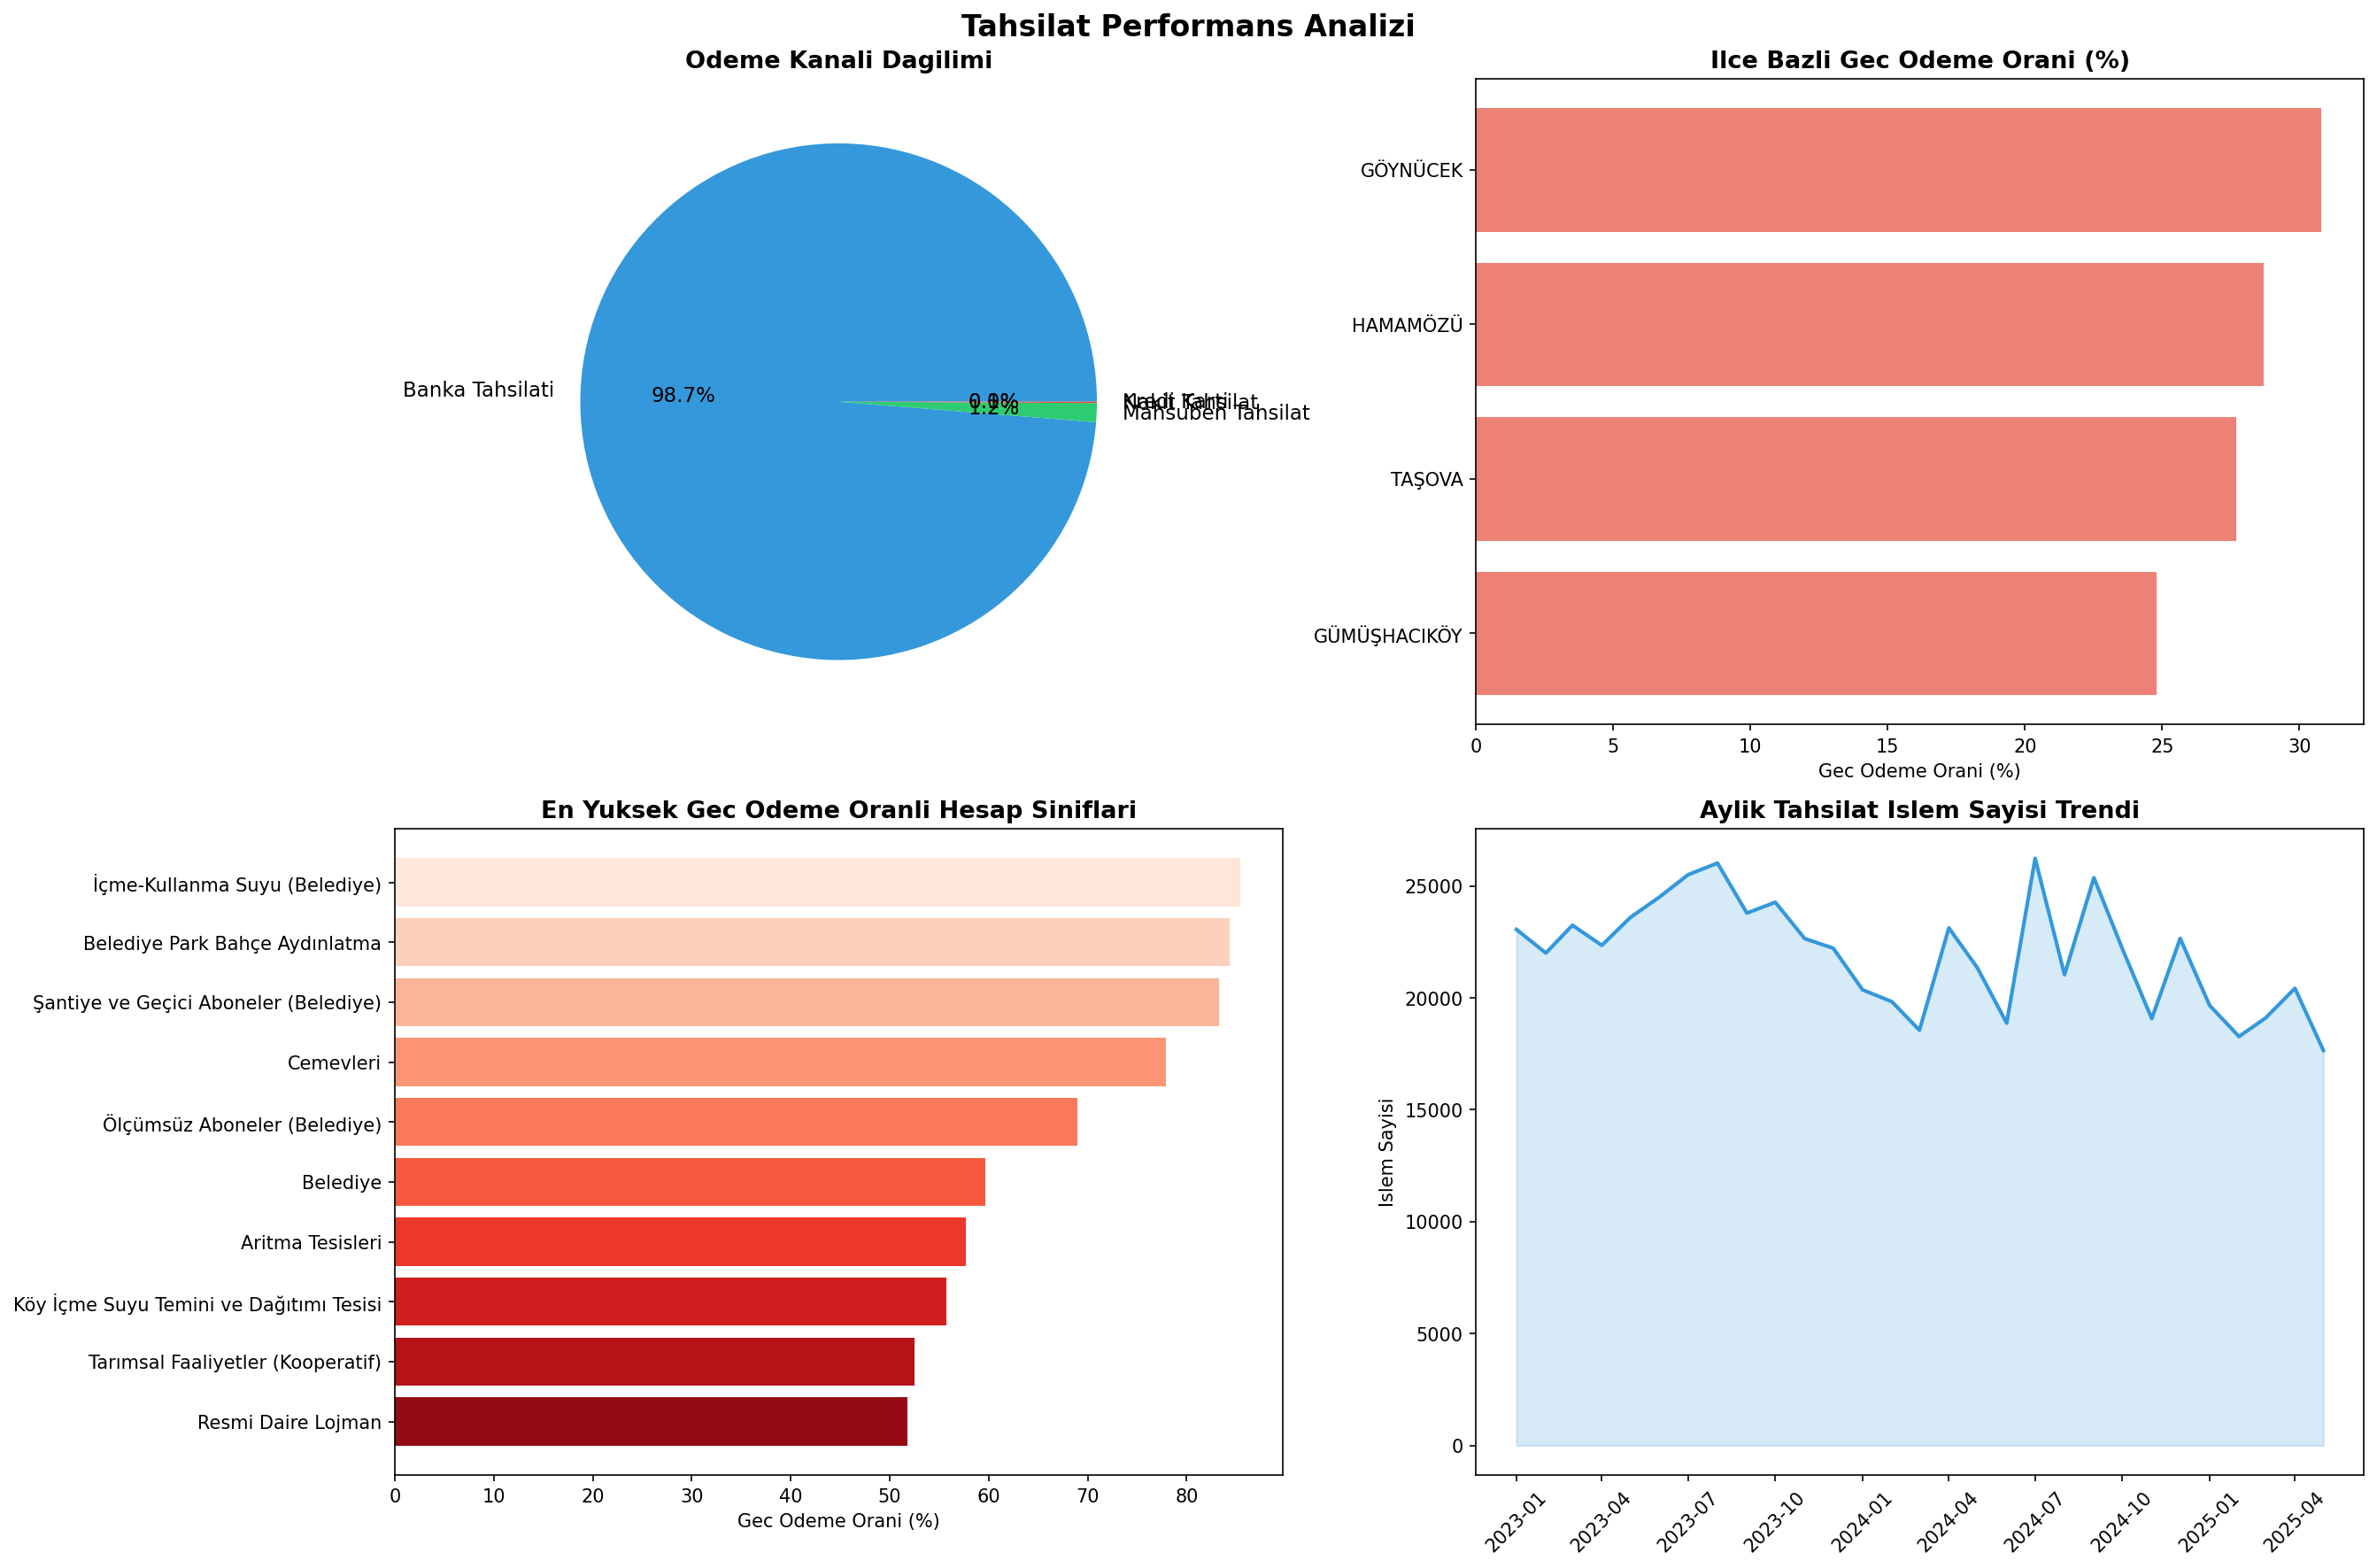

In [4]:
# 3.3 Tahsilat Performans Analizi

# Odeme kanali analizi
odeme_kanallari = {
    "Banka Tahsilati": df_tahsilat["Banka Tahsilatı"].notna().sum(),
    "Mahsuben Tahsilat": df_tahsilat["Mahsuben Tahsilat"].notna().sum(),
    "Nakit Tahsilat": df_tahsilat["Nakit Tahsilat"].notna().sum(),
    "Kredi Karti": df_tahsilat["Kredi Kartı Tahsilatı"].notna().sum()
}
odeme_df = pd.DataFrame.from_dict(odeme_kanallari, orient="index", columns=["Kayit Sayisi"])
odeme_df["Oran (%)"] = (odeme_df["Kayit Sayisi"] / len(df_tahsilat) * 100).round(1)
odeme_df = odeme_df.sort_values("Kayit Sayisi", ascending=False)
display(odeme_df)

# Hesap sinifi bazli gec odeme analizi
hesap_odeme = df_tahsilat_1.groupby("Hesap Sınıfı").agg(
    toplam_kayit=("gec_odeme_var", "count"),
    gec_kayit=("gec_odeme_var", "sum"),
    zamaninda_kayit=("zamaninda_odeme", "sum")
).reset_index()
hesap_odeme["gec_oran"] = (hesap_odeme["gec_kayit"] / hesap_odeme["toplam_kayit"] * 100).round(1)
hesap_odeme = hesap_odeme.sort_values("gec_oran", ascending=False)
display(hesap_odeme.head(15))

# Ilce bazli tahsilat performansi
ilce_tahsilat = df_tahsilat_1.groupby("İlçe").agg(
    toplam=("gec_odeme_var", "count"),
    gec=("gec_odeme_var", "sum"),
    zamaninda=("zamaninda_odeme", "sum")
).reset_index()
ilce_tahsilat["gec_oran"] = (ilce_tahsilat["gec"] / ilce_tahsilat["toplam"] * 100).round(1)
ilce_tahsilat["zamaninda_oran"] = (ilce_tahsilat["zamaninda"] / ilce_tahsilat["toplam"] * 100).round(1)
display(ilce_tahsilat)

# Gorsellestirme
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Tahsilat Performans Analizi", fontsize=16, fontweight="bold")

# Odeme kanali
axes[0, 0].pie(odeme_df["Kayit Sayisi"].values, labels=odeme_df.index,
               autopct="%1.1f%%", colors=["#3498db", "#2ecc71", "#e74c3c", "#f39c12"],
               textprops={"fontsize": 11})
axes[0, 0].set_title("Odeme Kanali Dagilimi", fontsize=13, fontweight="bold")

# Ilce bazli gec odeme orani
ilce_sorted = ilce_tahsilat.sort_values("gec_oran", ascending=True)
axes[0, 1].barh(ilce_sorted["İlçe"], ilce_sorted["gec_oran"], color="#e74c3c", alpha=0.7)
axes[0, 1].set_title("Ilce Bazli Gec Odeme Orani (%)", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Gec Odeme Orani (%)")

# Hesap sinifi bazli gec odeme (top 10)
top_hesap_odeme = hesap_odeme.head(10).sort_values("gec_oran", ascending=True)
axes[1, 0].barh(top_hesap_odeme["Hesap Sınıfı"], top_hesap_odeme["gec_oran"],
                color=sns.color_palette("Reds_r", len(top_hesap_odeme)))
axes[1, 0].set_title("En Yuksek Gec Odeme Oranli Hesap Siniflari", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Gec Odeme Orani (%)")

# Aylik tahsilat trendi
df_tahsilat["Tahsilat Tarihi"] = pd.to_datetime(df_tahsilat["Tahsilat Tarihi"])
aylik_tahsilat = df_tahsilat.groupby(df_tahsilat["Tahsilat Tarihi"].dt.to_period("M")).size()
aylik_tahsilat.index = aylik_tahsilat.index.to_timestamp()
axes[1, 1].plot(aylik_tahsilat.index, aylik_tahsilat.values, color="#3498db", linewidth=2)
axes[1, 1].fill_between(aylik_tahsilat.index, aylik_tahsilat.values, alpha=0.2, color="#3498db")
axes[1, 1].set_title("Aylik Tahsilat Islem Sayisi Trendi", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("Islem Sayisi")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/tahsilat_performans.png", dpi=150, bbox_inches="tight")
plt.show()